# LSST Time Series Classification
**Deep Learning for Time Series — Project**

Two settings:
- **Baselines**: 1D-FCN and InceptionTime trained from scratch
- **Competitor**: MOMENT and MANTIS Foundation Model

Dataset: LSST (Large Synoptic Survey Telescope) — 14 classes of astronomical objects, 6 channels, 36 time steps.

## 0. Install Dependencies

In [ ]:
!pip install -q git+https://github.com/moment-timeseries-foundation-model/moment.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tslearn.datasets import UCR_UEA_datasets

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Data Engineering

In [ ]:
# Load raw data
ds = UCR_UEA_datasets()
X_train_raw, y_train_raw, X_test_raw, y_test_raw = ds.load_dataset('LSST')

print('Raw shapes (N, T, C):')
print(f'  Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')
print(f'  Unique labels: {np.unique(y_train_raw)}')

Raw shapes (N, T, C):
  Train: (2459, 36, 6), Test: (2466, 36, 6)
  Unique labels: ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']


In [ ]:
# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)
N_CLASSES = len(le.classes_)
print(f'Number of classes: {N_CLASSES}')
print(f'Class mapping: {dict(zip(le.classes_, range(N_CLASSES)))}')

Number of classes: 14
Class mapping: {np.str_('15'): 0, np.str_('16'): 1, np.str_('42'): 2, np.str_('52'): 3, np.str_('53'): 4, np.str_('6'): 5, np.str_('62'): 6, np.str_('64'): 7, np.str_('65'): 8, np.str_('67'): 9, np.str_('88'): 10, np.str_('90'): 11, np.str_('92'): 12, np.str_('95'): 13}


In [ ]:
# Handle NaNs
# LSST has missing values — fill with channel mean
def fill_nans(X):
    X = X.copy()
    for i in range(X.shape[0]):
        for c in range(X.shape[2]):
            col = X[i, :, c]
            mask = np.isnan(col)
            if mask.any():
                col[mask] = np.nanmean(col) if not np.all(mask) else 0.0
                X[i, :, c] = col
    return X

X_train_raw = fill_nans(X_train_raw)
X_test_raw  = fill_nans(X_test_raw)
print('NaN filling done.')
print(f'Remaining NaNs — Train: {np.isnan(X_train_raw).sum()}, Test: {np.isnan(X_test_raw).sum()}')

NaN filling done.
Remaining NaNs — Train: 0, Test: 0


In [ ]:
# Reformat to PyTorch convention (N, C, T)
# tslearn returns (N, T, C) → we want (N, C, T)
X_train_pt = X_train_raw.transpose(0, 2, 1).astype(np.float32)  # (N, 6, 36)
X_test_pt  = X_test_raw.transpose(0, 2, 1).astype(np.float32)

N_CHANNELS = X_train_pt.shape[1]   # 6
T_ORIG     = X_train_pt.shape[2]   # 36
print(f'PyTorch shape: {X_train_pt.shape}  →  (N, C={N_CHANNELS}, T={T_ORIG})')

PyTorch shape: (2459, 6, 36)  →  (N, C=6, T=36)


In [ ]:
# Temporal interpolation to 512 (for MOMENT and Mantis)
import torch.nn.functional as F

T_MOMENT = 512

def interpolate_to(X_np, target_len):
    """Linearly interpolate time series from T_ORIG to target_len."""
    t = torch.tensor(X_np)          # (N, C, T)
    out = F.interpolate(t, size=target_len, mode='linear', align_corners=True)
    return out.numpy()

X_train_512 = interpolate_to(X_train_pt, T_MOMENT)   # (N, 6, 512)
X_test_512  = interpolate_to(X_test_pt,  T_MOMENT)
print(f'Interpolated shape: {X_train_512.shape}')

Interpolated shape: (2459, 6, 512)


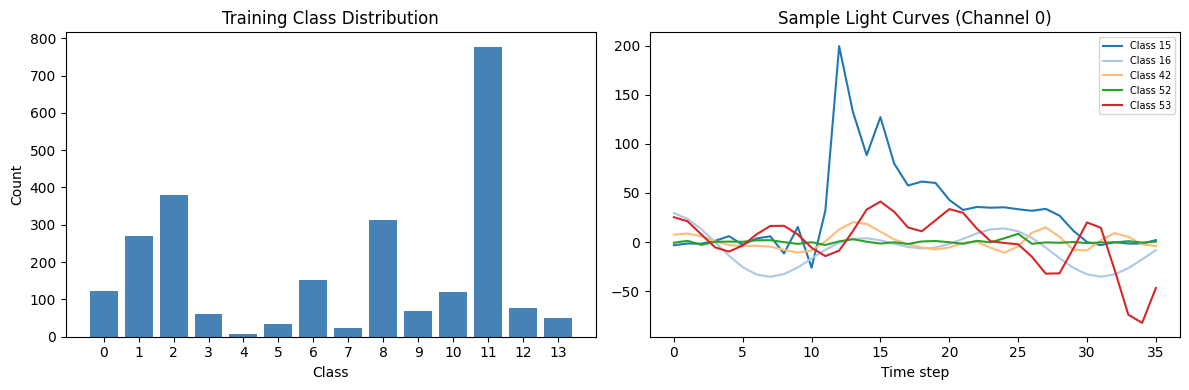

In [ ]:
# Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar(unique, counts, color='steelblue')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Training Class Distribution')
axes[0].set_xticks(unique)

# Sample light curves (one per class for channel 0)
colors = plt.cm.tab20(np.linspace(0, 1, N_CLASSES))
for cls in range(min(5, N_CLASSES)):
    idx = np.where(y_train == cls)[0][0]
    axes[1].plot(X_train_pt[idx, 0, :], color=colors[cls],
                 label=f'Class {le.classes_[cls]}')
axes[1].set_title('Sample Light Curves (Channel 0)')
axes[1].legend(fontsize=7)
axes[1].set_xlabel('Time step')

plt.tight_layout()
plt.savefig('eda.png', dpi=120)
plt.show()

## 3. Helper Utilities

In [ ]:
def make_loaders(X, y, batch_size=64, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate(model, loader, device, forward_fn=None):
    """Return accuracy and macro-F1. forward_fn allows custom forward passes."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            if forward_fn:
                logits = forward_fn(model, X_batch)
            else:
                logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, np.array(all_labels), np.array(all_preds)


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=120)
    plt.show()


def training_loop(model, train_loader, val_loader, optimizer, criterion,
                  n_epochs, device, forward_fn=None, scheduler=None):
    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = forward_fn(model, X_batch) if forward_fn else model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if scheduler:
            scheduler.step()
        avg_loss = total_loss / len(train_loader)
        acc, f1, _, _ = evaluate(model, val_loader, device, forward_fn)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(acc)
        history['val_f1'].append(f1)
        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{n_epochs} | Loss: {avg_loss:.4f} | '
                  f'Val Acc: {acc:.4f} | Val F1: {f1:.4f}')
    return history


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax2.plot(history['val_acc'],  label='Val Accuracy')
    ax2.plot(history['val_f1'],   label='Val F1 (Macro)')
    ax2.set_title(f'{title} — Metrics')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_history.png', dpi=120)
    plt.show()

print('Utilities defined.')

Utilities defined.


## 4. Baseline  : Fully Convolutional Network (FCN) and InceptionTime

In [ ]:
class FCN(nn.Module):
    """Fully Convolutional Network — classic TSC baseline (Wang et al. 2017).
    Input: (N, C, T)  →  Output: (N, n_classes)
    """
    def __init__(self, in_channels, n_classes):
        super().__init__()
        self.block1 = self._conv_block(in_channels, 128, kernel_size=8)
        self.block2 = self._conv_block(128, 256, kernel_size=5)
        self.block3 = self._conv_block(256, 128, kernel_size=3)
        self.gap    = nn.AdaptiveAvgPool1d(1)   # Global Average Pooling
        self.head   = nn.Linear(128, n_classes)

    def _conv_block(self, in_ch, out_ch, kernel_size):
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):          # x: (N, C, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)  # (N, 128)
        return self.head(x)          # (N, n_classes)


fcn = FCN(in_channels=N_CHANNELS, n_classes=N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in fcn.parameters() if p.requires_grad)
print(f'FCN parameters: {total_params:,}')

FCN parameters: 271,630


In [ ]:
# Data loaders (original 36 time steps)
from sklearn.model_selection import train_test_split

# Créer un val set depuis le train set (90/10)
idx = np.arange(len(X_train_pt))
idx_train, idx_val = train_test_split(idx, test_size=0.1,
                                       random_state=42,
                                       stratify=y_train)

train_loader = make_loaders(X_train_pt[idx_train], y_train[idx_train], batch_size=64)
val_loader   = make_loaders(X_train_pt[idx_val],   y_train[idx_val],   batch_size=64, shuffle=False)
test_loader  = make_loaders(X_test_pt,             y_test,             batch_size=64, shuffle=False)

Training FCN baseline...
  Epoch   1/70 | Loss: 0.9539 | Val Acc: 0.5203 | Val F1: 0.3500
  Epoch   5/70 | Loss: 0.8847 | Val Acc: 0.6098 | Val F1: 0.4080
  Epoch  10/70 | Loss: 0.9000 | Val Acc: 0.5610 | Val F1: 0.4216
  Epoch  15/70 | Loss: 0.8454 | Val Acc: 0.5569 | Val F1: 0.4259
  Epoch  20/70 | Loss: 0.8361 | Val Acc: 0.6179 | Val F1: 0.3708
  Epoch  25/70 | Loss: 0.8135 | Val Acc: 0.5285 | Val F1: 0.4009
  Epoch  30/70 | Loss: 0.7813 | Val Acc: 0.5650 | Val F1: 0.3804
  Epoch  35/70 | Loss: 0.7519 | Val Acc: 0.6423 | Val F1: 0.4158
  Epoch  40/70 | Loss: 0.7045 | Val Acc: 0.4837 | Val F1: 0.3221
  Epoch  45/70 | Loss: 0.6943 | Val Acc: 0.6138 | Val F1: 0.3899
  Epoch  50/70 | Loss: 0.6405 | Val Acc: 0.6341 | Val F1: 0.4284
  Epoch  55/70 | Loss: 0.6266 | Val Acc: 0.6220 | Val F1: 0.3867
  Epoch  60/70 | Loss: 0.6120 | Val Acc: 0.5610 | Val F1: 0.3584
  Epoch  65/70 | Loss: 0.6367 | Val Acc: 0.6341 | Val F1: 0.4162
  Epoch  70/70 | Loss: 0.6147 | Val Acc: 0.6382 | Val F1: 0.4173


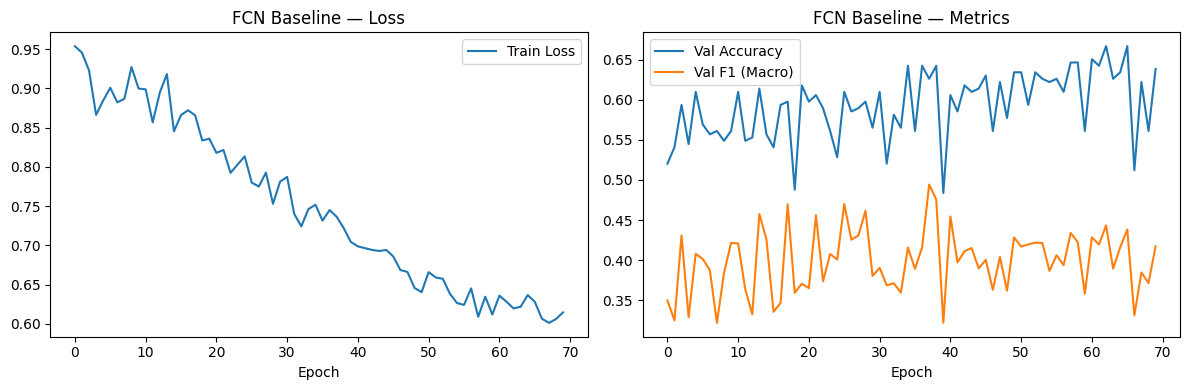

In [ ]:
# Training
optimizer_fcn = optim.Adam(fcn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_fcn = optim.lr_scheduler.CosineAnnealingLR(optimizer_fcn, T_max=70)
criterion     = nn.CrossEntropyLoss()

print('Training FCN baseline...')
history_fcn = training_loop(
    fcn, train_loader, val_loader,
    optimizer_fcn, criterion,
    n_epochs=70, device=DEVICE, scheduler=scheduler_fcn
)
plot_history(history_fcn, 'FCN Baseline')


[FCN Baseline] Test Accuracy: 0.6172 | Macro F1: 0.4410


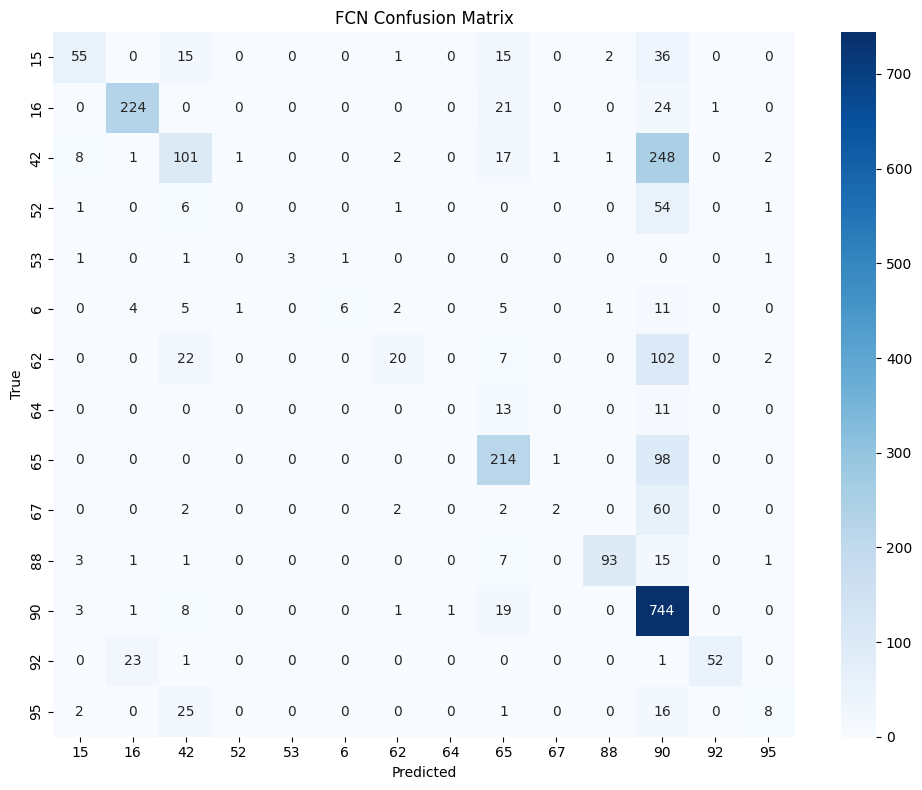

In [ ]:
# Final evaluation
acc_fcn, f1_fcn, y_true_fcn, y_pred_fcn = evaluate(fcn, test_loader, DEVICE)
print(f'\n[FCN Baseline] Test Accuracy: {acc_fcn:.4f} | Macro F1: {f1_fcn:.4f}')
plot_confusion_matrix(y_true_fcn, y_pred_fcn,
                      class_names=[str(c) for c in le.classes_],
                      title='FCN Confusion Matrix')

In [ ]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, nb_filters=32,
                 kernel_sizes=[3, 7, 13]):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, nb_filters,
                                    kernel_size=1, bias=False)
        self.convs = nn.ModuleList([
            nn.Conv1d(nb_filters, nb_filters, k, padding=k//2, bias=False)
            for k in kernel_sizes
        ])
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, nb_filters, kernel_size=1, bias=False)
        )
        self.bn      = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        bottleneck = self.bottleneck(x)
        branches   = [conv(bottleneck) for conv in self.convs]
        branches.append(self.maxpool_conv(x))
        out = torch.cat(branches, dim=1)
        return self.dropout(self.relu(self.bn(out)))


class InceptionTime(nn.Module):
    def __init__(self, in_channels, n_classes,
                 nb_filters=32,
                 depth=3):
        super().__init__()
        self.blocks    = nn.ModuleList()
        self.residuals = nn.ModuleList()
        out_channels   = nb_filters * 4

        current_channels = in_channels
        for i in range(depth):
            self.blocks.append(InceptionBlock(current_channels, nb_filters))
            if i % 3 == 2:
                group_start = in_channels if i == 2 else out_channels
                self.residuals.append(nn.Sequential(
                    nn.Conv1d(group_start, out_channels, 1, bias=False),
                    nn.BatchNorm1d(out_channels)
                ))
            current_channels = out_channels

        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(out_channels, n_classes)

    def forward(self, x):
        residual_input = x
        for i, block in enumerate(self.blocks):
            x = block(x)
            if i % 3 == 2:
                res = self.residuals[i // 3](residual_input)
                x = torch.relu(x + res)
                residual_input = x
        return self.head(self.gap(x).squeeze(-1))

In [ ]:
inception = InceptionTime(N_CHANNELS, N_CLASSES,
                           nb_filters=32, depth=3).to(DEVICE)

optimizer_inc = optim.Adam(inception.parameters(),
                            lr=3e-4,
                            weight_decay=1e-3)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=100)

history_inc = training_loop(
    inception, train_loader, val_loader,
    optimizer_inc, criterion,
    n_epochs=150,
    device=DEVICE, scheduler=scheduler_inc
)

  Epoch   1/150 | Loss: 2.5030 | Val Acc: 0.3455 | Val F1: 0.0739
  Epoch   5/150 | Loss: 1.8824 | Val Acc: 0.3862 | Val F1: 0.1091
  Epoch  10/150 | Loss: 1.6289 | Val Acc: 0.4593 | Val F1: 0.2662
  Epoch  15/150 | Loss: 1.4857 | Val Acc: 0.4878 | Val F1: 0.2969
  Epoch  20/150 | Loss: 1.4005 | Val Acc: 0.5041 | Val F1: 0.3067
  Epoch  25/150 | Loss: 1.3350 | Val Acc: 0.5163 | Val F1: 0.3392
  Epoch  30/150 | Loss: 1.2902 | Val Acc: 0.4959 | Val F1: 0.2525
  Epoch  35/150 | Loss: 1.2652 | Val Acc: 0.5122 | Val F1: 0.2517
  Epoch  40/150 | Loss: 1.2525 | Val Acc: 0.4878 | Val F1: 0.3279
  Epoch  45/150 | Loss: 1.2344 | Val Acc: 0.4878 | Val F1: 0.2435
  Epoch  50/150 | Loss: 1.1973 | Val Acc: 0.5081 | Val F1: 0.3431
  Epoch  55/150 | Loss: 1.1931 | Val Acc: 0.5285 | Val F1: 0.3518
  Epoch  60/150 | Loss: 1.1801 | Val Acc: 0.5366 | Val F1: 0.3720
  Epoch  65/150 | Loss: 1.1641 | Val Acc: 0.5081 | Val F1: 0.3268
  Epoch  70/150 | Loss: 1.1543 | Val Acc: 0.3211 | Val F1: 0.2833
  Epoch  7


[InceptionTime] Test Accuracy: 0.4736 | Macro F1: 0.2904


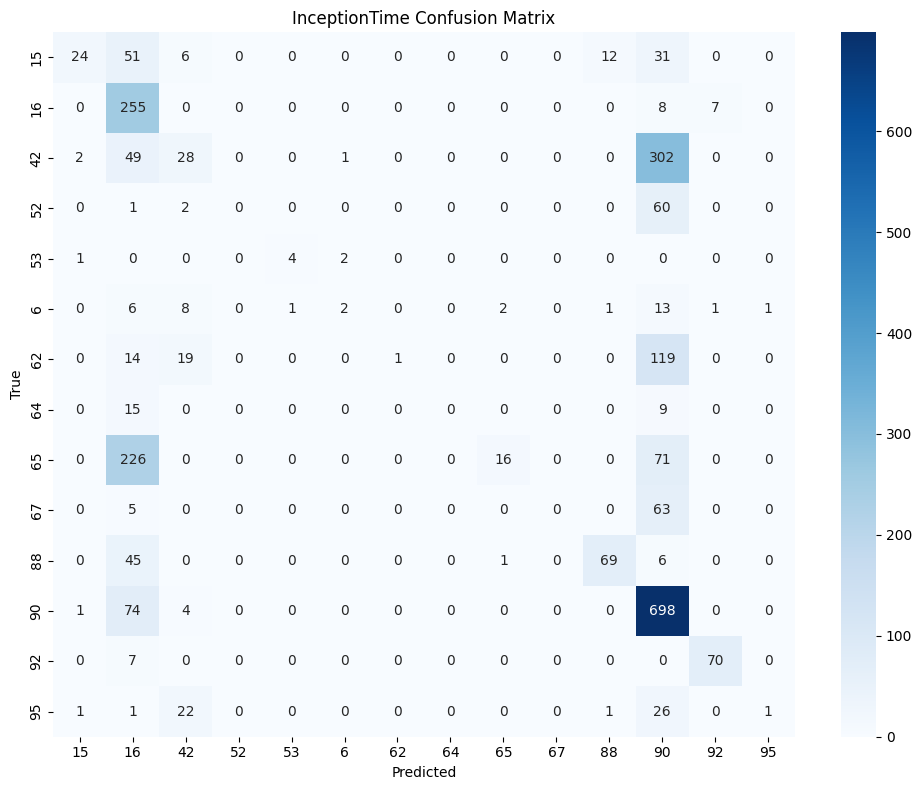

In [ ]:
acc_inc, f1_inc, y_true_inc, y_pred_inc = evaluate(inception, test_loader, DEVICE)
print(f'\n[InceptionTime] Test Accuracy: {acc_inc:.4f} | Macro F1: {f1_inc:.4f}')
plot_confusion_matrix(y_true_inc, y_pred_inc,
                      class_names=[str(c) for c in le.classes_],
                      title='InceptionTime Confusion Matrix')

## 5. Competitor : MOMENT and MANTIS (FM)

In [ ]:
!pip install -q moment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 32.4 MB/s eta 0:00:00


In [ ]:
from momentfm import MOMENTPipeline

# Load pre-trained MOMENT
moment = MOMENTPipeline.from_pretrained(
    'AutonLab/MOMENT-1-large',
    model_kwargs={
        'task_name'  : 'classification',
        'n_channels' : N_CHANNELS,      # 6
        'num_class'  : N_CLASSES,       # 14
    }
)
moment.init()
moment = moment.to(DEVICE)
print('MOMENT loaded successfully.')

total_params = sum(p.numel() for p in moment.parameters())
trainable    = sum(p.numel() for p in moment.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')

config.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

MOMENT loaded successfully.
Total params: 341,326,350 | Trainable: 86,030


In [ ]:
# Data loaders (512 time steps for MOMENT)
train_loader_moment = make_loaders(X_train_512, y_train, batch_size=32)
test_loader_moment  = make_loaders(X_test_512,  y_test,  batch_size=32, shuffle=False)

# MOMENT's forward pass returns a MOMENTOutputs object — we need .logits
def moment_forward(model, x):
    """x: (N, C, T=512)"""
    output = model(x_enc=x)
    return output.logits

print('Loaders ready.')

Loaders ready.


In [ ]:
#   Phase 1: Linear Probing (frozen backbone)
# Freeze the transformer backbone, only the classification head is trainable
for name, param in moment.named_parameters():
    if 'head' not in name and 'classifier' not in name:
        param.requires_grad = False

trainable_lp = sum(p.numel() for p in moment.parameters() if p.requires_grad)
print(f'Linear Probing — trainable params: {trainable_lp:,}')

optimizer_lp = optim.Adam(
    filter(lambda p: p.requires_grad, moment.parameters()),
    lr=1e-3
)

print('\n[Phase 1] Linear Probing...')
history_lp = training_loop(
    moment, train_loader_moment, test_loader_moment,
    optimizer_lp, criterion,
    n_epochs=10, device=DEVICE, forward_fn=moment_forward
)

acc_lp, f1_lp, _, _ = evaluate(moment, test_loader_moment, DEVICE, moment_forward)
print(f'\n[Linear Probing] Test Accuracy: {acc_lp:.4f} | Macro F1: {f1_lp:.4f}')

Linear Probing — trainable params: 86,030

[Phase 1] Linear Probing...
  Epoch   1/10 | Loss: 1.9033 | Val Acc: 0.4826 | Val F1: 0.1567
  Epoch   5/10 | Loss: 1.3234 | Val Acc: 0.5645 | Val F1: 0.2910
  Epoch  10/10 | Loss: 1.1844 | Val Acc: 0.6099 | Val F1: 0.3521

[Linear Probing] Test Accuracy: 0.6099 | Macro F1: 0.3521


In [ ]:
# Phase 2: Full Fine-tuning (unfreeze everything)
for param in moment.parameters():
    param.requires_grad = True

trainable_ft = sum(p.numel() for p in moment.parameters() if p.requires_grad)
print(f'Full Fine-tuning — trainable params: {trainable_ft:,}')

# Very low LR to avoid catastrophic forgetting of pre-trained weights
optimizer_ft = optim.Adam(moment.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20)

print('\n[Phase 2] Full Fine-tuning...')
history_ft = training_loop(
    moment, train_loader_moment, test_loader_moment,
    optimizer_ft, criterion,
    n_epochs=5, device=DEVICE,
    forward_fn=moment_forward, scheduler=scheduler_ft
)


Full Fine-tuning — trainable params: 341,326,350

[Phase 2] Full Fine-tuning...
  Epoch   1/5 | Loss: 1.1161 | Val Acc: 0.6164 | Val F1: 0.3578
  Epoch   5/5 | Loss: 0.8078 | Val Acc: 0.6630 | Val F1: 0.4637



[MOMENT Fine-tuned] Test Accuracy: 0.6630 | Macro F1: 0.4637


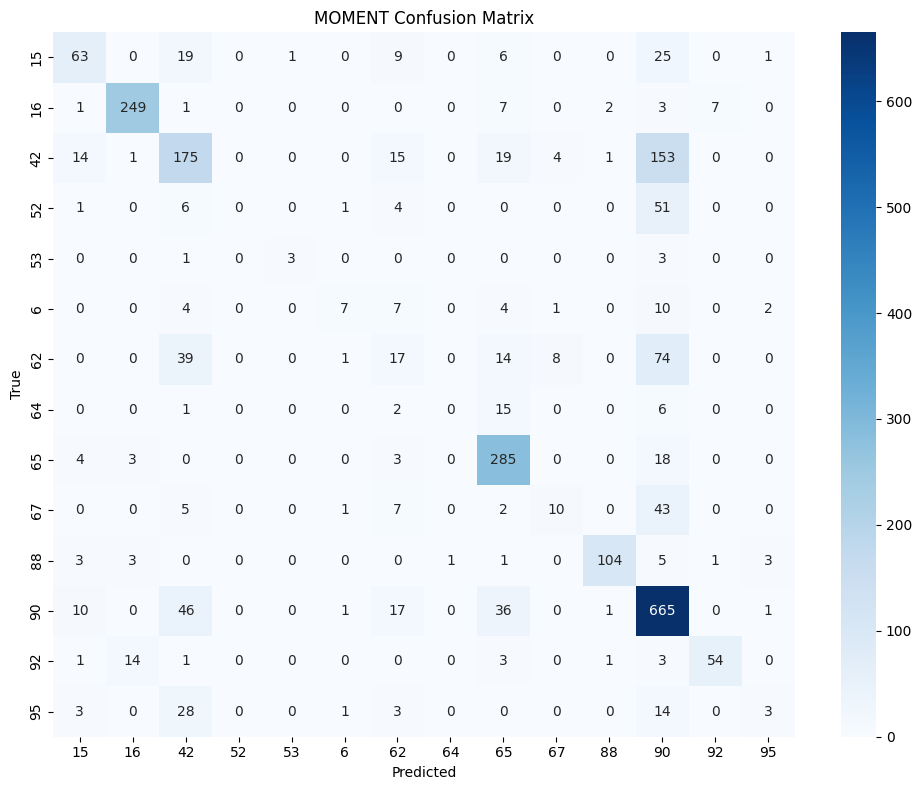

In [ ]:
# Final evaluation
acc_ft, f1_ft, y_true_ft, y_pred_ft = evaluate(
    moment, test_loader_moment, DEVICE, moment_forward
)
print(f'\n[MOMENT Fine-tuned] Test Accuracy: {acc_ft:.4f} | Macro F1: {f1_ft:.4f}')
plot_confusion_matrix(y_true_ft, y_pred_ft,
                      class_names=[str(c) for c in le.classes_],
                      title='MOMENT Confusion Matrix')

In [ ]:
!pip install mantis-tsfm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 36.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0


In [ ]:
# Load pre-trained Mantis
from mantis.architecture import Mantis8M
from mantis.trainer import MantisTrainer
from mantis.adapters import LinearChannelCombiner
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load the 8M parameter pretrained ViT from HuggingFace
MANTIS_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
network = Mantis8M(device=MANTIS_DEVICE)
network = network.from_pretrained("paris-noah/Mantis-8M")

print(f'Mantis loaded on {MANTIS_DEVICE}')
total_params = sum(p.numel() for p in network.parameters())
print(f'Total parameters: {total_params:,}')   # ~8M vs MOMENT's 385M

config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.5M [00:00<?, ?B/s]

Mantis loaded on cuda
Total parameters: 8,103,936


In [ ]:
# Phase 1: Zero-shot Feature Extraction
mantis_frozen = MantisTrainer(device=MANTIS_DEVICE, network=network)

print('Extracting train embeddings (frozen backbone)...')
Z_train = mantis_frozen.transform(X_train_512)
print('Extracting test  embeddings (frozen backbone)...')
Z_test  = mantis_frozen.transform(X_test_512)
print(f'Embedding shape: {Z_train.shape}')

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
clf.fit(Z_train, y_train)

y_pred_zs    = clf.predict(Z_test)
acc_mantis_zs = accuracy_score(y_test, y_pred_zs)
f1_mantis_zs  = f1_score(y_test, y_pred_zs, average='macro', zero_division=0)
print(f'\n[Mantis Zero-shot] Test Accuracy: {acc_mantis_zs:.4f} | Macro F1: {f1_mantis_zs:.4f}')

Extracting train embeddings (frozen backbone)...
Extracting test  embeddings (frozen backbone)...
Embedding shape: (2459, 1536)

[Mantis Zero-shot] Test Accuracy: 0.6038 | Macro F1: 0.5043


In [ ]:
#  Phase 2: Fine-tuning with LinearChannelCombiner adapter
# The adapter compresses 6 channels → 3 channels before the ViT backbone.
# Then both the adapter AND the classification head are trained jointly,
# while the backbone stays frozen. This is 'adapter_head' mode.
#
# Why 3 new channels?  6 is already small, but the adapter helps the model
# learn which combinations of photometric bands are most discriminative,
# rather than treating them all independently.

network_ft = Mantis8M(device=MANTIS_DEVICE)
network_ft  = network_ft.from_pretrained("paris-noah/Mantis-8M")

mantis_ft = MantisTrainer(device=MANTIS_DEVICE, network=network_ft)
adapter   = LinearChannelCombiner(num_channels=N_CHANNELS,
                                  new_num_channels=3)

print('Fine-tuning Mantis (adapter + head)...')
mantis_ft.fit(
    X_train_512, y_train,
    adapter=adapter,
    fine_tuning_type='adapter_head'   # trains adapter + head, backbone frozen
)


Fine-tuning Mantis (adapter + head)...


Epoch 499: Train Loss 0.5211: 100%|██████████| 500/500 [38:56<00:00,  4.67s/it]


FineTuningNetwork(
  (encoder): Mantis8M(
    (tokgen_unit): TokenGeneratorUnit(
      (convs): ModuleList(
        (0-1): 2 x Convolution(
          (conv): Conv1d(1, 256, kernel_size=(17,), stride=(1,), padding=(8,))
        )
      )
      (layer_norms): ModuleList(
        (0-1): 2 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
      (scalar_encoders): ModuleList(
        (0-1): 2 x MultiScaledScalarEncoder(
          (encoders): ModuleList(
            (0-8): 9 x ScalarEncoder(
              (layer_norm): LayerNorm((32,), eps=1e-15, elementwise_affine=True)
            )
          )
        )
      )
      (linear_encoder): LinearEncoder(
        (linear): Linear(in_features=576, out_features=256, bias=True)
        (layer_norm): LayerNorm((256,), eps=1e-15, elementwise_affine=True)
      )
    )
    (vit_unit): ViTUnit(
      (pos_encoder): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (laye

In [ ]:
y_pred_ft  = mantis_ft.predict(X_test_512)
acc_mantis_ft = accuracy_score(y_test, y_pred_ft)
f1_mantis_ft  = f1_score(y_test, y_pred_ft, average='macro', zero_division=0)
print(f'\n[Mantis Fine-tuned] Test Accuracy: {acc_mantis_ft:.4f} | Macro F1: {f1_mantis_ft:.4f}')


[Mantis Fine-tuned] Test Accuracy: 0.6196 | Macro F1: 0.4769


## 6. Results Comparison


Model                            Accuracy     Macro F1
FCN                                0.6172       0.4410
InceptionTime                      0.4736       0.2904
MOMENT – Linear Probe              0.6099       0.3521
MOMENT – Full FT                   0.6630       0.4637
Mantis – Zero-shot                 0.6038       0.5043
Mantis – Fine-tuned                0.6196       0.4769


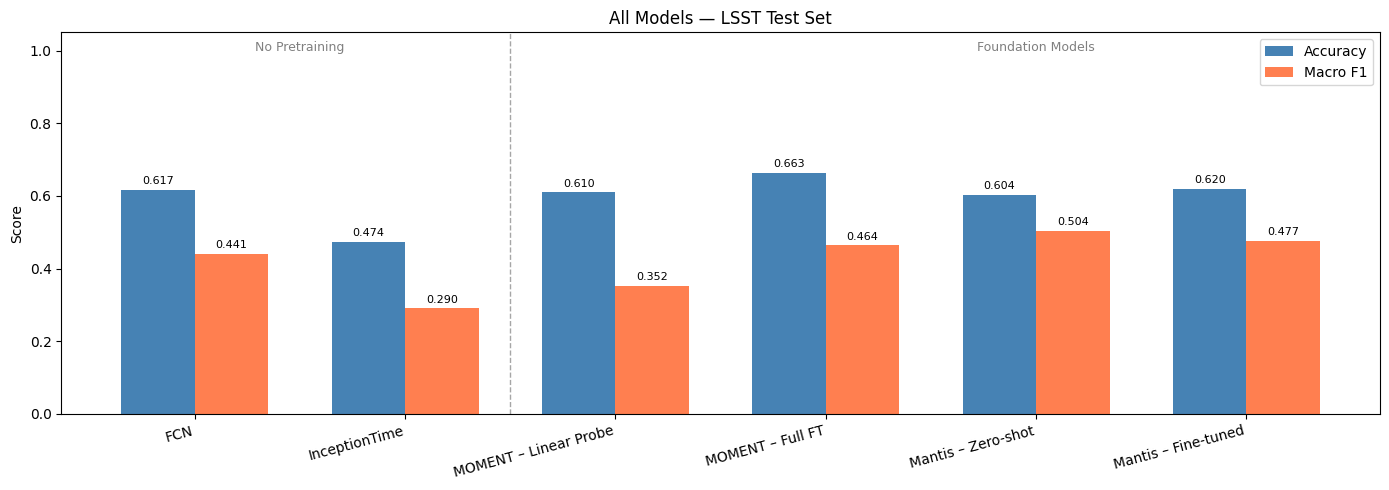

In [ ]:
results = {
    'Model': [
        'FCN',
        'InceptionTime',
        'MOMENT – Linear Probe',
        'MOMENT – Full FT',
        'Mantis – Zero-shot',
        'Mantis – Fine-tuned',
    ],
    'Test Accuracy': [acc_fcn, acc_inc, acc_lp, acc_ft,  acc_mantis_zs, acc_mantis_ft],
    'Macro F1':      [f1_fcn,  f1_inc,  f1_lp,  f1_ft,   f1_mantis_zs,  f1_mantis_ft],
}

# Table
print('\n' + '='*60)
print(f'{"Model":<28} {"Accuracy":>12} {"Macro F1":>12}')
print('='*60)
for m, a, f in zip(results['Model'], results['Test Accuracy'], results['Macro F1']):
    print(f'{m:<28} {a:>12.4f} {f:>12.4f}')
print('='*60)

# Bar chart
x = np.arange(len(results['Model']))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_acc = ax.bar(x - w/2, results['Test Accuracy'], w,
                  label='Accuracy', color='steelblue')
bars_f1  = ax.bar(x + w/2, results['Macro F1'],      w,
                  label='Macro F1', color='coral')

# Add value labels on top of each bar
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Vertical separator between baselines and foundation models
ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(0.5,  0.95, 'No Pretraining', transform=ax.get_xaxis_transform(),
        ha='center', color='gray', fontsize=9)
ax.text(4.0,  0.95, 'Foundation Models', transform=ax.get_xaxis_transform(),
        ha='center', color='gray', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Models — LSST Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=120)
plt.show()